## 1. Librerías

In [1]:
import os
from pathlib import Path
import requests
import boto3
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape, box
import rasterio
from rasterio.session import AWSSession
from rasterio.mask import mask
from rasterio.features import geometry_mask
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from IPython.display import display
import leafmap
import xarray as xr
import leafmap
import time
from rasterio.transform import from_origin
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds, Window

## 2. Conexión con CDSE S3

In [2]:
os.environ["AWS_ACCESS_KEY_ID"] ="6LGUYM0AH1085NRUCNQ9"
os.environ["AWS_SECRET_ACCESS_KEY"] = "G5BQxqO4zYSe26YiGsaclgO4RRtaxOpxOVBg0W6n"
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["AWS_HTTPS"] = "YES"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"
boto3_session = boto3.Session()
s3_client = boto3_session.client("s3", endpoint_url="https://eodata.dataspace.copernicus.eu")
rio_session = AWSSession(boto3_session, endpoint_url="eodata.dataspace.copernicus.eu")

## 3. AOI cuadrado de Ayapel

In [3]:
AOI_FILE = Path("AOI_Ayapel.geojson")
OUTPUT_DIR = Path("resultados_ayapel_mosaicos_cuadrado")
OUTPUT_DIR.mkdir(exist_ok=True)
if not AOI_FILE.exists():
    raise FileNotFoundError("Coloca AOI_Ayapel.geojson junto al notebook.")
aoi = gpd.read_file(AOI_FILE)
if aoi.empty or aoi.crs is None:
    raise ValueError("El AOI está vacío o no tiene CRS.")
aoi = aoi[aoi.geometry.notna() & ~aoi.geometry.is_empty].copy()
if not aoi.geometry.is_valid.all():
    aoi["geometry"] = aoi.geometry.make_valid()
aoi_wgs84 = aoi.to_crs("EPSG:4326")
aoi_geometry = aoi_wgs84.geometry.union_all()
aoi_wkt = aoi_geometry.wkt
search_wkt = box(*aoi_wgs84.total_bounds).wkt
center = aoi_geometry.centroid
print("Archivo:", AOI_FILE, "| Polígonos:", len(aoi), "| CRS:", aoi.crs)
print("Límites:", aoi_wgs84.total_bounds)
map_aoi = leafmap.Map(center=[center.y, center.x], zoom=13, scale_control=True)
map_aoi.add_basemap("Esri.WorldImagery")
map_aoi.add_gdf(aoi_wgs84, layer_name="AOI cuadrado de Ayapel")
display(map_aoi)

Archivo: AOI_Ayapel.geojson | Polígonos: 1 | CRS: EPSG:4326
Límites: [-75.16   8.29 -75.08   8.37]


Map(center=[8.329999999999998, -75.11999999999999], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## 4. Dos periodos a comparar

In [4]:
START_DATE_1 = "2024-03-01"
END_DATE_1 = "2024-03-31"
START_DATE_2 = "2024-11-01"
END_DATE_2 = "2024-11-30"
CATALOGUE_URL = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

## 5.1. Escenas de marzo que cubren el AOI

In [5]:
filter_query = (
    "Collection/Name eq 'SENTINEL-2' and "
    "Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq 'S2MSI2A') and "
    f"OData.CSC.Intersects(area=geography'SRID=4326;{search_wkt}') and "
    f"ContentDate/Start ge {START_DATE_1}T00:00:00.000Z and "
    f"ContentDate/Start le {END_DATE_1}T23:59:59.999Z"
)
params = {"$filter": filter_query, "$expand": "Attributes", "$orderby": "ContentDate/Start desc", "$top": 100}
url = CATALOGUE_URL
items = []
while url is not None:
    response = requests.get(url, params=params, timeout=90)
    response.raise_for_status()
    data = response.json()
    items.extend(data["value"])
    url = data.get("@odata.nextLink")
    params = None
scenes_1 = []
for item in items:
    footprint = shape(item["GeoFootprint"])
    if not footprint.covers(aoi_geometry):
        continue
    cloud_cover = None
    for attribute in item.get("Attributes", []):
        if attribute.get("Name") == "cloudCover" and attribute.get("Value") is not None:
            cloud_cover = float(attribute["Value"])
    if cloud_cover is None:
        continue
    scene = {"date": item["ContentDate"]["Start"].split("T")[0], "name": item["Name"], "s3_path": item["S3Path"], "cloud_cover": cloud_cover}
    scenes_1.append(scene)
    print(scene["date"], "| Nubes (%):", cloud_cover, "|", scene["name"])
    print("S3:", scene["s3_path"])
if not scenes_1:
    raise ValueError("No se encontraron escenas que cubran todo el AOI en el periodo 1.")
print("Escenas del periodo 1:", len(scenes_1))

2024-03-28 | Nubes (%): 29.416126 | S2A_MSIL2A_20240328T152651_N0510_R025_T18PVQ_20240328T220315.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/03/28/S2A_MSIL2A_20240328T152651_N0510_R025_T18PVQ_20240328T220315.SAFE
2024-03-23 | Nubes (%): 100.0 | S2B_MSIL2A_20240323T152649_N0510_R025_T18PVQ_20240323T192012.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/03/23/S2B_MSIL2A_20240323T152649_N0510_R025_T18PVQ_20240323T192012.SAFE
2024-03-18 | Nubes (%): 43.364885 | S2A_MSIL2A_20240318T152651_N0510_R025_T18PVQ_20240318T201052.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/03/18/S2A_MSIL2A_20240318T152651_N0510_R025_T18PVQ_20240318T201052.SAFE
2024-03-13 | Nubes (%): 54.767364 | S2B_MSIL2A_20240313T152649_N0510_R025_T18PVQ_20240313T194622.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/03/13/S2B_MSIL2A_20240313T152649_N0510_R025_T18PVQ_20240313T194622.SAFE
2024-03-08 | Nubes (%): 54.191965 | S2A_MSIL2A_20240308T152651_N0510_R025_T18PVQ_20240308T204653.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/03/08/S2A_MSIL2A_20240308T

## 5.2. Escenas de noviembre que cubren el AOI

In [6]:
filter_query = (
    "Collection/Name eq 'SENTINEL-2' and "
    "Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq 'S2MSI2A') and "
    f"OData.CSC.Intersects(area=geography'SRID=4326;{search_wkt}') and "
    f"ContentDate/Start ge {START_DATE_2}T00:00:00.000Z and "
    f"ContentDate/Start le {END_DATE_2}T23:59:59.999Z"
)
params = {"$filter": filter_query, "$expand": "Attributes", "$orderby": "ContentDate/Start desc", "$top": 100}
url = CATALOGUE_URL
items = []
while url is not None:
    response = requests.get(url, params=params, timeout=90)
    response.raise_for_status()
    data = response.json()
    items.extend(data["value"])
    url = data.get("@odata.nextLink")
    params = None
scenes_2 = []
for item in items:
    footprint = shape(item["GeoFootprint"])
    if not footprint.covers(aoi_geometry):
        continue
    cloud_cover = None
    for attribute in item.get("Attributes", []):
        if attribute.get("Name") == "cloudCover" and attribute.get("Value") is not None:
            cloud_cover = float(attribute["Value"])
    if cloud_cover is None:
        continue
    scene = {"date": item["ContentDate"]["Start"].split("T")[0], "name": item["Name"], "s3_path": item["S3Path"], "cloud_cover": cloud_cover}
    scenes_2.append(scene)
    print(scene["date"], "| Nubes (%):", cloud_cover, "|", scene["name"])
    print("S3:", scene["s3_path"])
if not scenes_2:
    raise ValueError("No se encontraron escenas que cubran todo el AOI en el periodo 2.")
print("Escenas del periodo 2:", len(scenes_2))

2024-11-28 | Nubes (%): 83.207905 | S2B_MSIL2A_20241128T152659_N0511_R025_T18PVQ_20241128T191139.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/11/28/S2B_MSIL2A_20241128T152659_N0511_R025_T18PVQ_20241128T191139.SAFE
2024-11-26 | Nubes (%): 79.54275 | S2A_MSIL2A_20241126T153621_N0511_R068_T18PVQ_20241126T205151.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/11/26/S2A_MSIL2A_20241126T153621_N0511_R068_T18PVQ_20241126T205151.SAFE
2024-11-23 | Nubes (%): 75.25996 | S2A_MSIL2A_20241123T152651_N0511_R025_T18PVQ_20241123T203700.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/11/23/S2A_MSIL2A_20241123T152651_N0511_R025_T18PVQ_20241123T203700.SAFE
2024-11-18 | Nubes (%): 43.626252 | S2B_MSIL2A_20241118T152649_N0511_R025_T18PVQ_20241118T192356.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/11/18/S2B_MSIL2A_20241118T152649_N0511_R025_T18PVQ_20241118T192356.SAFE
2024-11-13 | Nubes (%): 30.57808 | S2A_MSIL2A_20241113T152651_N0511_R025_T18PVQ_20241113T203206.SAFE
S3: /eodata/Sentinel-2/MSI/L2A/2024/11/13/S2A_MSIL2A_20241113

## 6. Elegir fechas de cada periodo y localizar sus bandas en S3

In [7]:
MAX_SCENES_PER_PERIOD = 3  # Usa None para promediar todas las fechas (más lento).
for state in [1, 2]:
    candidates = scenes_1 if state == 1 else scenes_2
    candidates = sorted(candidates, key=lambda scene: scene["cloud_cover"])
    chosen = []
    used_dates = set()
    for scene in candidates:
        if scene["date"] in used_dates:
            continue
        chosen.append(scene)
        used_dates.add(scene["date"])
        if MAX_SCENES_PER_PERIOD is not None and len(chosen) >= MAX_SCENES_PER_PERIOD:
            break
    print("Periodo", state, "| Fechas elegidas:", [(scene["date"], round(scene["cloud_cover"], 2)) for scene in chosen])
    if state == 1:
        scenes_1 = chosen
    else:
        scenes_2 = chosen
for scenes in [scenes_1, scenes_2]:
    for scene in scenes:
        product_path = scene["s3_path"].replace("/eodata/", "", 1)
        paths = {}
        paginator = s3_client.get_paginator("list_objects_v2")
        for page in paginator.paginate(Bucket="eodata", Prefix=product_path + "/"):
            for file in page.get("Contents", []):
                key = file["Key"]
                for band in ["B04", "B03", "B02"]:
                    if key.endswith("_" + band + "_10m.jp2"):
                        paths[band] = "/vsis3/eodata/" + key
        if any(band not in paths for band in ["B04", "B03", "B02"]):
            raise ValueError("Faltan bandas B04/B03/B02 en " + scene["name"])
        scene["paths"] = paths
        print(scene["date"], "|", scene["name"], "| B04:", paths["B04"])
print("Para procesar: marzo", len(scenes_1), "escenas | noviembre", len(scenes_2), "escenas")

Periodo 1 | Fechas elegidas: [('2024-03-03', 18.8), ('2024-03-28', 29.42), ('2024-03-06', 41.2)]
Periodo 2 | Fechas elegidas: [('2024-11-13', 30.58), ('2024-11-18', 43.63), ('2024-11-06', 73.41)]
2024-03-03 | S2B_MSIL2A_20240303T152649_N0510_R025_T18PVQ_20240303T191251.SAFE | B04: /vsis3/eodata/Sentinel-2/MSI/L2A/2024/03/03/S2B_MSIL2A_20240303T152649_N0510_R025_T18PVQ_20240303T191251.SAFE/GRANULE/L2A_T18PVQ_A036516_20240303T152648/IMG_DATA/R10m/T18PVQ_20240303T152649_B04_10m.jp2
2024-03-28 | S2A_MSIL2A_20240328T152651_N0510_R025_T18PVQ_20240328T220315.SAFE | B04: /vsis3/eodata/Sentinel-2/MSI/L2A/2024/03/28/S2A_MSIL2A_20240328T152651_N0510_R025_T18PVQ_20240328T220315.SAFE/GRANULE/L2A_T18PVQ_A045782_20240328T153032/IMG_DATA/R10m/T18PVQ_20240328T152651_B04_10m.jp2
2024-03-06 | S2B_MSIL2A_20240306T153619_N0510_R068_T18PVQ_20240306T204910.SAFE | B04: /vsis3/eodata/Sentinel-2/MSI/L2A/2024/03/06/S2B_MSIL2A_20240306T153619_N0510_R068_T18PVQ_20240306T204910.SAFE/GRANULE/L2A_T18PVQ_A036559_20240

## 7. Cuadrícula común para todo el AOI (20 m)

In [8]:
target_crs = aoi.estimate_utm_crs()
aoi_projected = aoi.to_crs(target_crs)
minx, miny, maxx, maxy = aoi_projected.total_bounds
resolution = 10
width = int(np.ceil((maxx - minx) / resolution))
height = int(np.ceil((maxy - miny) / resolution))
target_transform = from_origin(minx, maxy, resolution, resolution)
inside_aoi = geometry_mask(list(aoi_projected.geometry), out_shape=(height, width), transform=target_transform, invert=True)
print("CRS:", target_crs, "| Resolución:", resolution, "m | Tamaño:", (height, width))
print("Píxeles dentro del AOI:", int(inside_aoi.sum()))

CRS: EPSG:32618 | Resolución: 10 m | Tamaño: (885, 882)
Píxeles dentro del AOI: 779453


## 8. Mosaico RGB de marzo: media de todos los píxeles disponibles

Leyendo: 2024-03-03 | S2B_MSIL2A_20240303T152649_N0510_R025_T18PVQ_20240303T191251.SAFE
Procesada: 2024-03-03 | Píxeles disponibles: 779453 | Segundos: 46.2
Leyendo: 2024-03-28 | S2A_MSIL2A_20240328T152651_N0510_R025_T18PVQ_20240328T220315.SAFE
Procesada: 2024-03-28 | Píxeles disponibles: 779453 | Segundos: 37.8
Leyendo: 2024-03-06 | S2B_MSIL2A_20240306T153619_N0510_R068_T18PVQ_20240306T204910.SAFE
Procesada: 2024-03-06 | Píxeles disponibles: 779453 | Segundos: 84.4
Cobertura del AOI: 100.0 %
Observaciones por píxel (máximo): 3


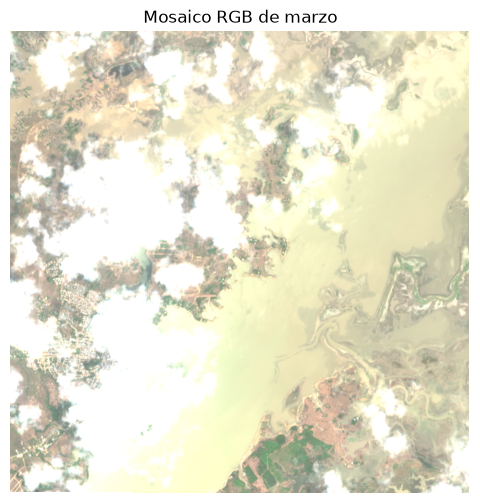

In [9]:
sum_rgb_1 = np.zeros((3, height, width), dtype="float32")
count_rgb_1 = np.zeros((height, width), dtype="uint16")
for scene in scenes_1:
    started = time.perf_counter()
    print("Leyendo:", scene["date"], "|", scene["name"], flush=True)
    paths = scene["paths"]
    with rasterio.Env(session=rio_session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(paths["B04"]) as src:
            left, bottom, right, top = transform_bounds(src.crs, target_crs, *src.bounds)
            left, bottom = max(minx, left), max(maxy - height * resolution, bottom)
            right, top = min(minx + width * resolution, right), min(maxy, top)
            if right <= left or top <= bottom:
                print("Sin intersección espacial:", scene["date"], flush=True)
                continue
            bounds_window = from_bounds(left, bottom, right, top, transform=target_transform)
            col0 = max(0, int(np.floor(bounds_window.col_off)))
            row0 = max(0, int(np.floor(bounds_window.row_off)))
            col1 = min(width, int(np.ceil(bounds_window.col_off + bounds_window.width)))
            row1 = min(height, int(np.ceil(bounds_window.row_off + bounds_window.height)))
            window = Window(col0, row0, col1 - col0, row1 - row0)
            rows, cols = slice(row0, row1), slice(col0, col1)
        rgb = np.zeros((3, row1 - row0, col1 - col0), dtype="float32")
        for index, band in enumerate(["B04", "B03", "B02"]):
            with rasterio.open(paths[band]) as src:
                with WarpedVRT(src, crs=target_crs, transform=target_transform, width=width, height=height, resampling=Resampling.average, src_nodata=0, nodata=0) as vrt:
                    rgb[index] = vrt.read(1, window=window)
    available = inside_aoi[rows, cols] & np.all(rgb > 0, axis=0)
    rgb_sum = sum_rgb_1[:, rows, cols]
    rgb_count = count_rgb_1[rows, cols]
    rgb_sum[:, available] += rgb[:, available]
    rgb_count[available] += 1
    print("Procesada:", scene["date"], "| Píxeles disponibles:", int(available.sum()), "| Segundos:", round(time.perf_counter() - started, 1), flush=True)
has_data_1 = inside_aoi & (count_rgb_1 > 0)
mosaic_1 = np.full((3, height, width), np.nan, dtype="float32")
mosaic_1[:, has_data_1] = sum_rgb_1[:, has_data_1] / count_rgb_1[has_data_1]
print("Cobertura del AOI:", round(100 * has_data_1.sum() / inside_aoi.sum(), 2), "%")
print("Observaciones por píxel (máximo):", int(count_rgb_1.max()))
preview = np.moveaxis(mosaic_1, 0, -1)
plt.figure(figsize=(7, 6))
plt.imshow(np.clip(preview / 3000, 0, 1))
plt.title("Mosaico RGB de marzo")
plt.axis("off")
plt.show()

## 9. Mosaico RGB de noviembre: media de todos los píxeles disponibles

Leyendo: 2024-11-13 | S2A_MSIL2A_20241113T152651_N0511_R025_T18PVQ_20241113T203206.SAFE
Procesada: 2024-11-13 | Píxeles disponibles: 779453 | Segundos: 36.5
Leyendo: 2024-11-18 | S2B_MSIL2A_20241118T152649_N0511_R025_T18PVQ_20241118T192356.SAFE
Procesada: 2024-11-18 | Píxeles disponibles: 779453 | Segundos: 36.3
Leyendo: 2024-11-06 | S2A_MSIL2A_20241106T153621_N0511_R068_T18PVQ_20241106T204953.SAFE
Procesada: 2024-11-06 | Píxeles disponibles: 779453 | Segundos: 82.5
Cobertura del AOI: 100.0 %
Observaciones por píxel (máximo): 3


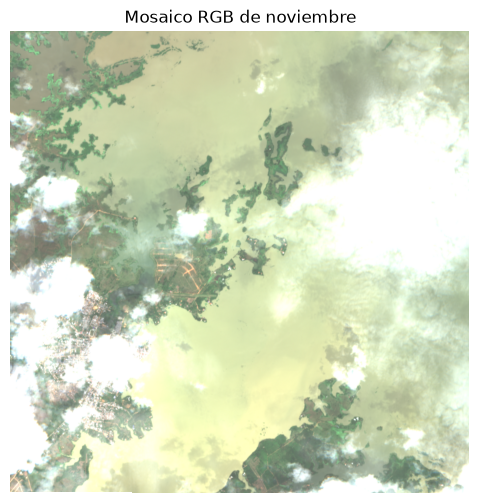

In [10]:
sum_rgb_2 = np.zeros((3, height, width), dtype="float32")
count_rgb_2 = np.zeros((height, width), dtype="uint16")
for scene in scenes_2:
    started = time.perf_counter()
    print("Leyendo:", scene["date"], "|", scene["name"], flush=True)
    paths = scene["paths"]
    with rasterio.Env(session=rio_session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(paths["B04"]) as src:
            left, bottom, right, top = transform_bounds(src.crs, target_crs, *src.bounds)
            left, bottom = max(minx, left), max(maxy - height * resolution, bottom)
            right, top = min(minx + width * resolution, right), min(maxy, top)
            if right <= left or top <= bottom:
                print("Sin intersección espacial:", scene["date"], flush=True)
                continue
            bounds_window = from_bounds(left, bottom, right, top, transform=target_transform)
            col0 = max(0, int(np.floor(bounds_window.col_off)))
            row0 = max(0, int(np.floor(bounds_window.row_off)))
            col1 = min(width, int(np.ceil(bounds_window.col_off + bounds_window.width)))
            row1 = min(height, int(np.ceil(bounds_window.row_off + bounds_window.height)))
            window = Window(col0, row0, col1 - col0, row1 - row0)
            rows, cols = slice(row0, row1), slice(col0, col1)
        rgb = np.zeros((3, row1 - row0, col1 - col0), dtype="float32")
        for index, band in enumerate(["B04", "B03", "B02"]):
            with rasterio.open(paths[band]) as src:
                with WarpedVRT(src, crs=target_crs, transform=target_transform, width=width, height=height, resampling=Resampling.average, src_nodata=0, nodata=0) as vrt:
                    rgb[index] = vrt.read(1, window=window)
    available = inside_aoi[rows, cols] & np.all(rgb > 0, axis=0)
    rgb_sum = sum_rgb_2[:, rows, cols]
    rgb_count = count_rgb_2[rows, cols]
    rgb_sum[:, available] += rgb[:, available]
    rgb_count[available] += 1
    print("Procesada:", scene["date"], "| Píxeles disponibles:", int(available.sum()), "| Segundos:", round(time.perf_counter() - started, 1), flush=True)
has_data_2 = inside_aoi & (count_rgb_2 > 0)
mosaic_2 = np.full((3, height, width), np.nan, dtype="float32")
mosaic_2[:, has_data_2] = sum_rgb_2[:, has_data_2] / count_rgb_2[has_data_2]
print("Cobertura del AOI:", round(100 * has_data_2.sum() / inside_aoi.sum(), 2), "%")
print("Observaciones por píxel (máximo):", int(count_rgb_2.max()))
preview = np.moveaxis(mosaic_2, 0, -1)
plt.figure(figsize=(7, 6))
plt.imshow(np.clip(preview / 3000, 0, 1))
plt.title("Mosaico RGB de noviembre")
plt.axis("off")
plt.show()

## 10. Diferencia entre los dos mosaicos y estadísticas

In [11]:
valid_both = has_data_1 & has_data_2
if not valid_both.any():
    raise ValueError("Los dos mosaicos no tienen píxeles en común.")
missing = inside_aoi & ~valid_both
print("Píxeles sin ninguna observación en ambos periodos:", int(missing.sum()))
if missing.any():
    print("Amplía los periodos si quieres cubrir estas zonas; no existen píxeles para promediarlas.")
difference = np.full((height, width), np.nan, dtype="float32")
difference[valid_both] = ((mosaic_2[0, valid_both] - mosaic_1[0, valid_both]) + (mosaic_2[1, valid_both] - mosaic_1[1, valid_both]) + (mosaic_2[2, valid_both] - mosaic_1[2, valid_both])) / 3
difference_da = xr.DataArray(difference, dims=("y", "x"), name="diferencia_rgb_dn")
values = difference_da.values[valid_both]
stats = pd.DataFrame({"estadistico": ["media", "minimo", "maximo", "desviacion_estandar", "pixeles_comparados", "porcentaje_AOI_comparable"], "valor": [float(values.mean()), float(values.min()), float(values.max()), float(values.std()), int(values.size), float(100 * valid_both.sum() / inside_aoi.sum())]})
display(stats)
stats.to_csv(OUTPUT_DIR / "estadisticas_mosaicos.csv", index=False)
print("Diferencia = promedio de B04/B03/B02 de noviembre menos marzo, en DN.")

Píxeles sin ninguna observación en ambos periodos: 0


,estadistico,valor
0,media,-374.962555
1,minimo,-7131.333496
2,maximo,6320.000000
3,desviacion_estandar,1198.273682
4,pixeles_comparados,779453.000000
5,porcentaje_AOI_comparable,100.000000


Diferencia = promedio de B04/B03/B02 de noviembre menos marzo, en DN.


## 11. Exportar estados y diferencia como GeoTIFF georreferenciados

In [12]:
nodata_value = -9999.0
rgb_profile = {"driver": "GTiff", "height": height, "width": width, "count": 3, "dtype": "float32", "crs": target_crs, "transform": target_transform, "nodata": nodata_value, "compress": "deflate", "tiled": True}
diff_profile = rgb_profile.copy()
diff_profile["count"] = 1
file_1 = OUTPUT_DIR / "Ayapel_RGB_mosaico_marzo_2024.tif"
file_2 = OUTPUT_DIR / "Ayapel_RGB_mosaico_noviembre_2024.tif"
file_difference = OUTPUT_DIR / "Ayapel_diferencia_RGB_noviembre_menos_marzo_2024.tif"
with rasterio.open(file_1, "w", **rgb_profile) as dst:
    dst.write(np.where(np.isfinite(mosaic_1), mosaic_1, nodata_value).astype("float32"))
    dst.descriptions = ("B04 rojo", "B03 verde", "B02 azul")
with rasterio.open(file_2, "w", **rgb_profile) as dst:
    dst.write(np.where(np.isfinite(mosaic_2), mosaic_2, nodata_value).astype("float32"))
    dst.descriptions = ("B04 rojo", "B03 verde", "B02 azul")
with rasterio.open(file_difference, "w", **diff_profile) as dst:
    dst.write(np.where(np.isfinite(difference), difference, nodata_value).astype("float32"), 1)
    dst.set_band_description(1, "Promedio de diferencias B04/B03/B02")
    dst.update_tags(estado_1="marzo 2024", estado_2="noviembre 2024", nota="media de todas las observaciones disponibles por periodo")
with rasterio.open(file_difference) as src:
    assert src.crs == target_crs and src.transform == target_transform
    print("GeoTIFF de diferencia:", file_difference.resolve(), "| CRS:", src.crs, "| Resolución:", src.res)

GeoTIFF de diferencia: /workspace/TALLER_4/resultados_ayapel_mosaicos_cuadrado/Ayapel_diferencia_RGB_noviembre_menos_marzo_2024.tif | CRS: EPSG:32618 | Resolución: (10.0, 10.0)


## 12. Histograma de la diferencia

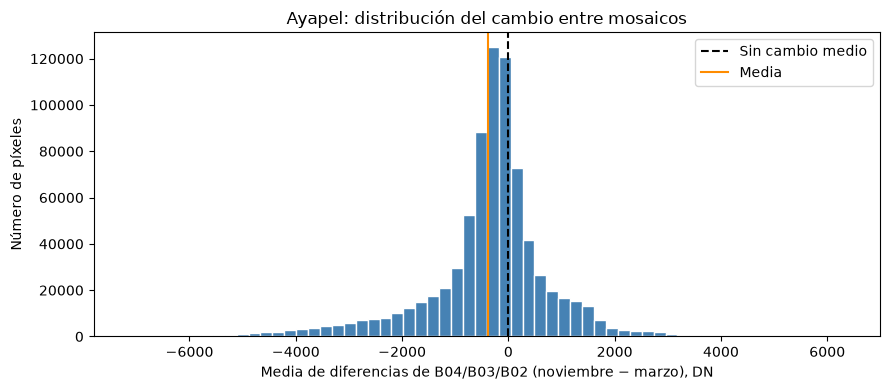

In [13]:
plt.figure(figsize=(9, 4))
plt.hist(values, bins=60, color="steelblue", edgecolor="white")
plt.axvline(0, color="black", linestyle="--", label="Sin cambio medio")
plt.axvline(values.mean(), color="darkorange", label="Media")
plt.xlabel("Media de diferencias de B04/B03/B02 (noviembre − marzo), DN")
plt.ylabel("Número de píxeles")
plt.title("Ayapel: distribución del cambio entre mosaicos")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "histograma_mosaicos.png", dpi=180)
plt.show()

## 13. Diferencia entre imágenes

In [14]:
difference_limit = max(float(np.percentile(np.abs(values), 98)), 1.0)
m = leafmap.Map(center=[center.y, center.x], zoom=13, draw_control=True, measure_control=True, fullscreen_control=True, scale_control=True, layers_control=True)
m.add_basemap("Esri.WorldImagery")
m.add_raster(str(file_1), indexes=[1, 2, 3], vmin=0, vmax=3000, nodata=nodata_value, layer_name="Estado 1: mosaico RGB marzo", visible=False)
m.add_raster(str(file_2), indexes=[1, 2, 3], vmin=0, vmax=3000, nodata=nodata_value, layer_name="Estado 2: mosaico RGB noviembre", visible=False)
m.add_raster(str(file_difference), colormap="coolwarm", vmin=-difference_limit, vmax=difference_limit, nodata=nodata_value, layer_name="Diferencia noviembre − marzo")
m.add_gdf(aoi_wgs84, layer_name="Contorno del AOI", style={"color": "black", "weight": 2, "fillOpacity": 0})
m.add_colorbar(colors=["#3b4cc0", "#8db0fe", "#dddcdc", "#f4987a", "#b40426"], vmin=-difference_limit, vmax=difference_limit, caption="Cambio promedio B04/B03/B02 (DN)")
display(m)

Map(center=[8.329986000000002, -75.119969], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

## 14. Slide comparación

In [15]:
comparison_map = leafmap.Map(center=[center.y, center.x], zoom=13, scale_control=True)
comparison_map.split_map(left_layer=str(file_1), right_layer=str(file_2), left_args={"indexes": [1, 2, 3], "vmin": 0, "vmax": 3000, "nodata": nodata_value}, right_args={"indexes": [1, 2, 3], "vmin": 0, "vmax": 3000, "nodata": nodata_value}, left_label="Marzo 2024 (mosaico)", right_label="Noviembre 2024 (mosaico)")
display(comparison_map)
print("Resultados en:", OUTPUT_DIR.resolve())

Map(center=[8.329999999999998, -75.11999999999999], controls=(ZoomControl(options=['position', 'zoom_in_text',…

Resultados en: /workspace/TALLER_4/resultados_ayapel_mosaicos_cuadrado
